# **Project Introduction**

🛒 Customer Segmentation & Revenue Analysis

## Objective
Analyze retail transaction data to:
- Understand revenue drivers
- Explore customer purchasing behaviour
- Segment customers using RFM and clustering techniques

## Dataset
Online retail transactional dataset containing:
- Invoice data
- Product details
- Customer information

The goal of this analysis is to transform raw retail transaction data into actionable insights that could support better business decisions and customer-focused strategies.

Note: Dataset is UK-dominant, which may influence geographic insights

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
sns.set_style('whitegrid')

# **2. Load Dataset**

In [ ]:
df= pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Ecom project/Online Retail.xlsx')

# **3. Initial Data Exploration**

Understanding dataset structure, data types, and missing values.

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


# **4. Data Understanding**

In [ ]:
#Summary Statistics
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
#Missing Values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#Invalid Values (Negative Quantity)
df[df['Quantity'] < 0].shape

(0, 9)

In [ ]:
#Duplicate checks
df.duplicated().sum()

np.int64(0)

# **5. Data Cleaning and Validation**

In [ ]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled transactions
df = df[df['Quantity'] > 0]

# Remove duplicates
df = df.drop_duplicates()

# Convert data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Validation check
df.shape
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0


- Removed missing CustomerID values
- Filtered out cancelled transactions (negative Quantity)
- Removed duplicate records
- Converted InvoiceDate to datetime format
- Created Revenue feature

Post-cleaning validation confirms:
- No missing CustomerID values
- Only valid transactions retained

# **6. Exploratory Data Analysis (EDA)**


This section focuses on identifying key revenue drivers, top-performing products, and geographic trends.

**6.1 Revenue Trend**

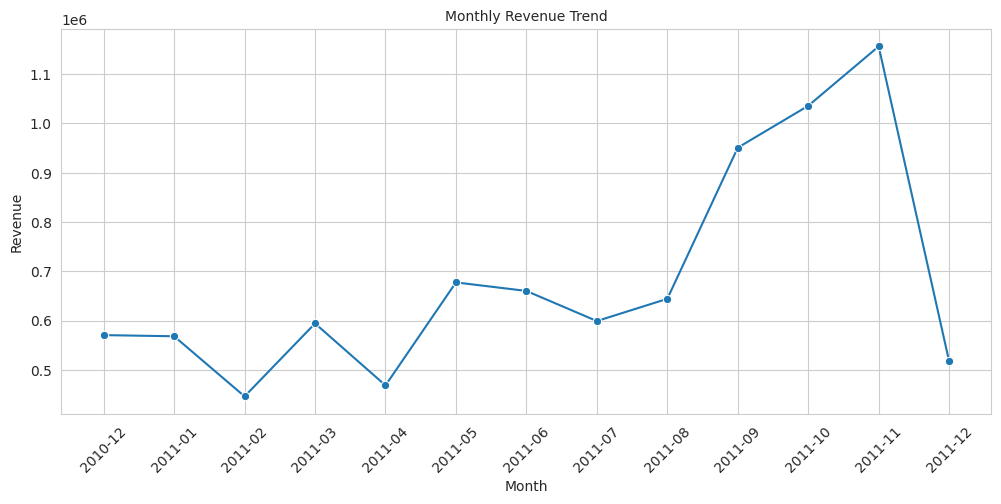

In [ ]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue', marker='o')

plt.title('Monthly Revenue Trend', fontsize=10)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

**6.2 Top Products (Revenue Drivers)**

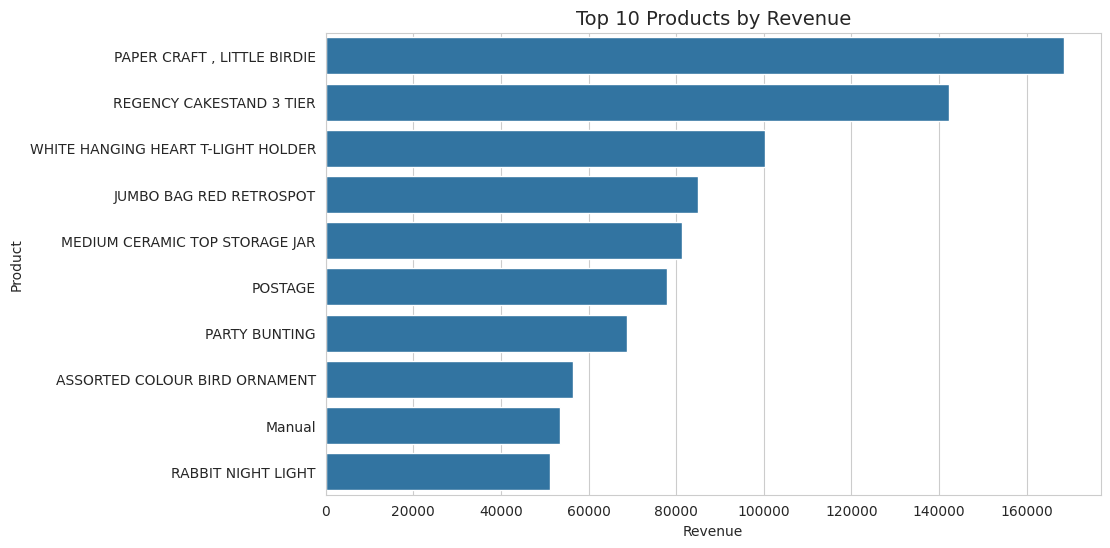

In [ ]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_products, y='Description', x='Revenue')

plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

**6.3 Geographic Analysis**

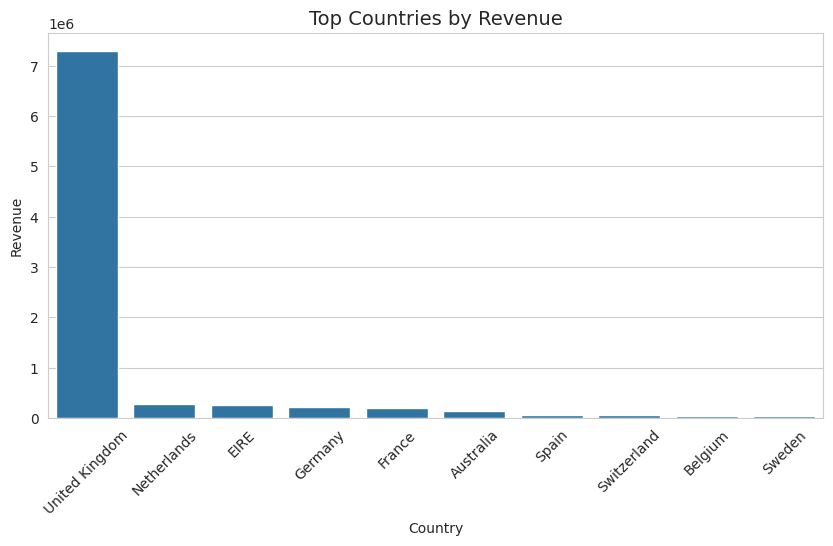

In [ ]:
top_countries = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=top_countries, x='Country', y='Revenue')

plt.title('Top Countries by Revenue', fontsize=14)
plt.xticks(rotation=45)

plt.show()

**6.3.1 UK vs International Revenue**

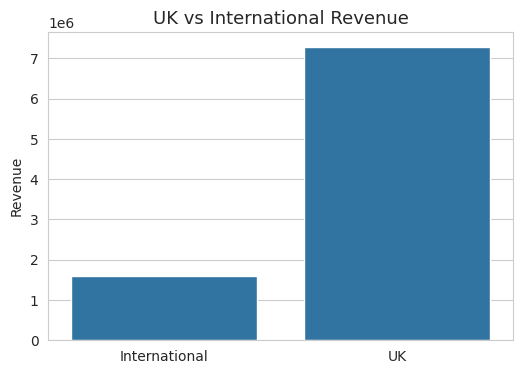

In [ ]:
df['Region'] = df['Country'].apply(
    lambda x: 'UK' if x == 'United Kingdom' else 'International'
)

region_sales = (
    df.groupby('Region')['Revenue']
    .sum()
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(data=region_sales, x='Region', y='Revenue')

plt.title('UK vs International Revenue', fontsize=13)
plt.xlabel('')
plt.ylabel('Revenue')

plt.show()

**6.3.2 Top Countries (Excluding UK)**

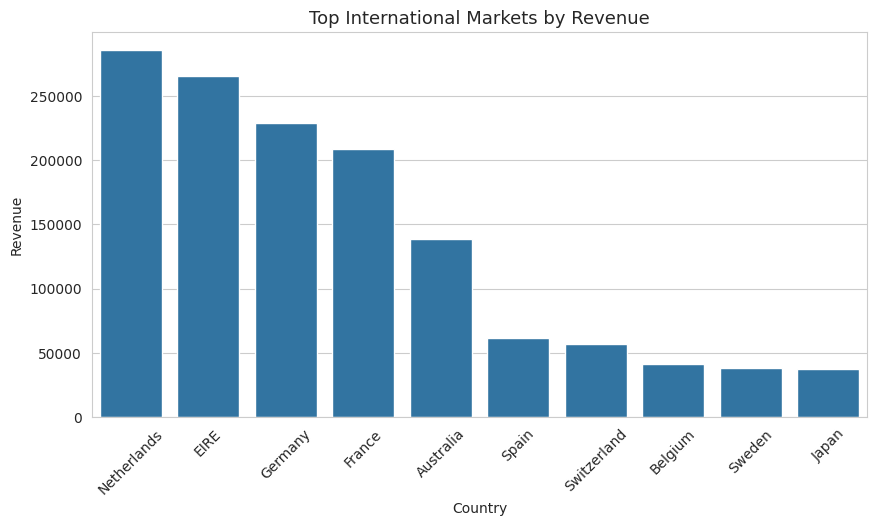

In [ ]:
df_non_uk = df[df['Country'] != 'United Kingdom']

top_countries = (
    df_non_uk.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=top_countries, x='Country', y='Revenue')

plt.title('Top International Markets by Revenue', fontsize=13)
plt.xticks(rotation=45)

plt.show()

**6.4 Top Customers**

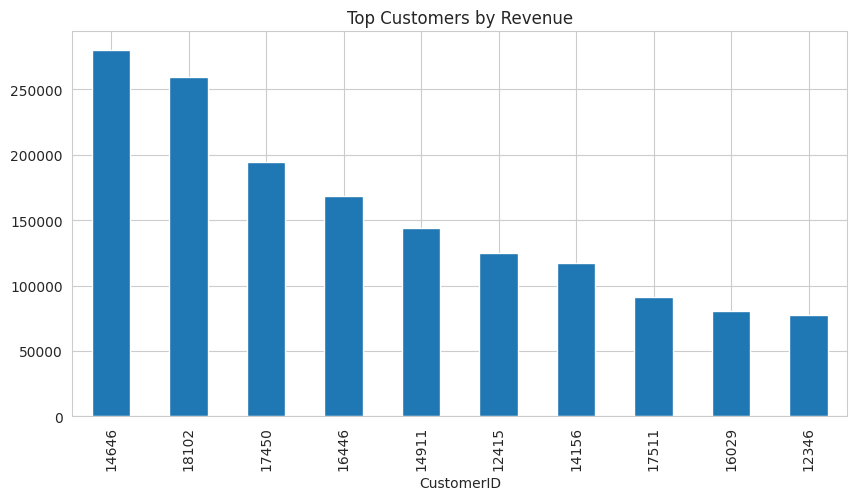

In [ ]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind='bar', figsize=(10,5))
plt.title('Top Customers by Revenue')
plt.show()

**Business Context**

- The dataset is heavily concentrated in the UK market
- However, international revenue contribution indicates potential for expansion
- While not used in the segmentation model, geographic insights help inform business strategy

# **7. Customer Behaviour Analysis**

This section explores how customers interact with the business, focusing on purchase frequency and repeat behaviour.

**7.1 Repeat vs One time Customers**

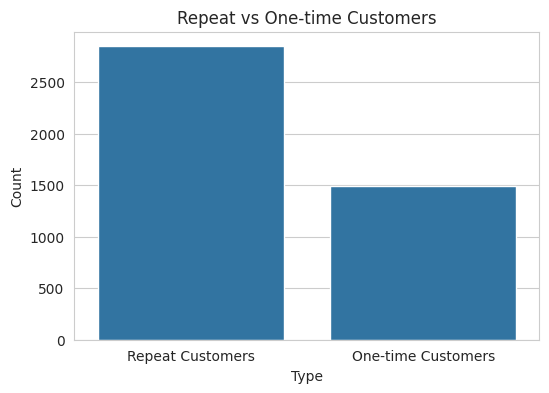

In [ ]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

customer_type = pd.DataFrame({
    'Type': ['Repeat Customers', 'One-time Customers'],
    'Count': [repeat_customers, one_time_customers]
})

plt.figure(figsize=(6,4))
sns.barplot(data=customer_type, x='Type', y='Count')

plt.title('Repeat vs One-time Customers')
plt.show()

**7.2 Purchase Frequency Distribution**

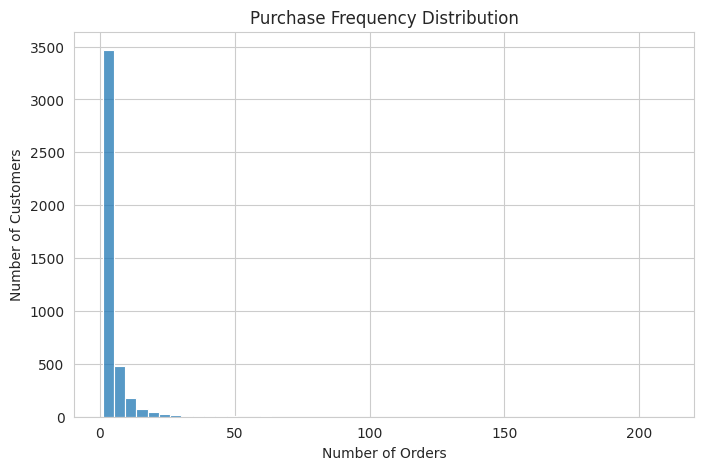

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(customer_orders, bins=50)

plt.title('Purchase Frequency Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.show()

**7.3 Revenue by Customer**

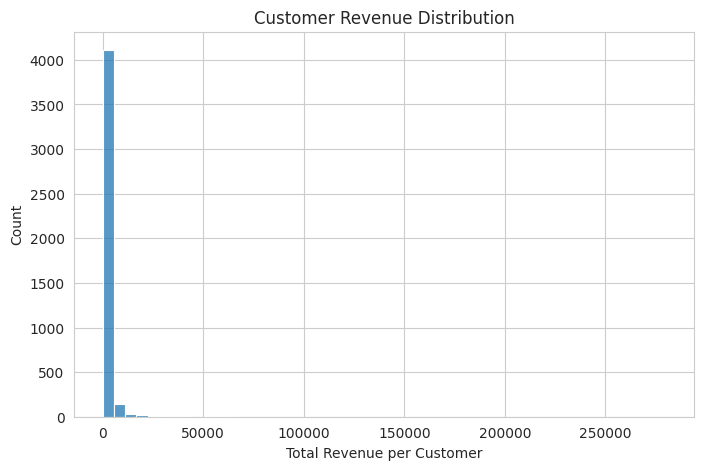

In [ ]:
customer_revenue = (
    df.groupby('CustomerID')['Revenue']
    .sum()
)

plt.figure(figsize=(8,5))
sns.histplot(customer_revenue, bins=50)

plt.title('Customer Revenue Distribution')
plt.xlabel('Total Revenue per Customer')

plt.show()

**Log Transformation**

- Revenue distribution is highly skewed, with most customers contributing low revenue
- Log transformation reveals underlying distribution more clearly
- A small segment of customers contributes significantly higher revenue

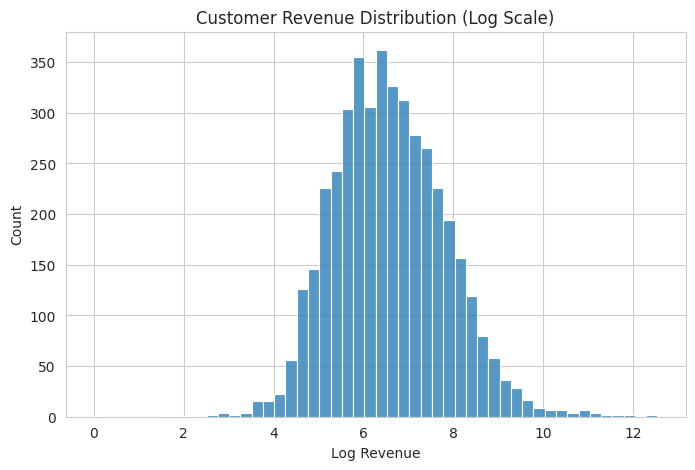

In [ ]:
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(customer_revenue), bins=50)

plt.title('Customer Revenue Distribution (Log Scale)')
plt.xlabel('Log Revenue')

plt.show()

# **8. RFM Segmentation**


Customers are segmented based on:
- Recency: How recently a customer made a purchase
- Frequency: How often they purchase
- Monetary: How much they spend

**8.1 Build RFM Table**

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### RFM Metrics

- Recency: Number of days since last purchase
- Frequency: Number of unique transactions
- Monetary: Total revenue generated by the customer

**8.2 RFM Distributions**

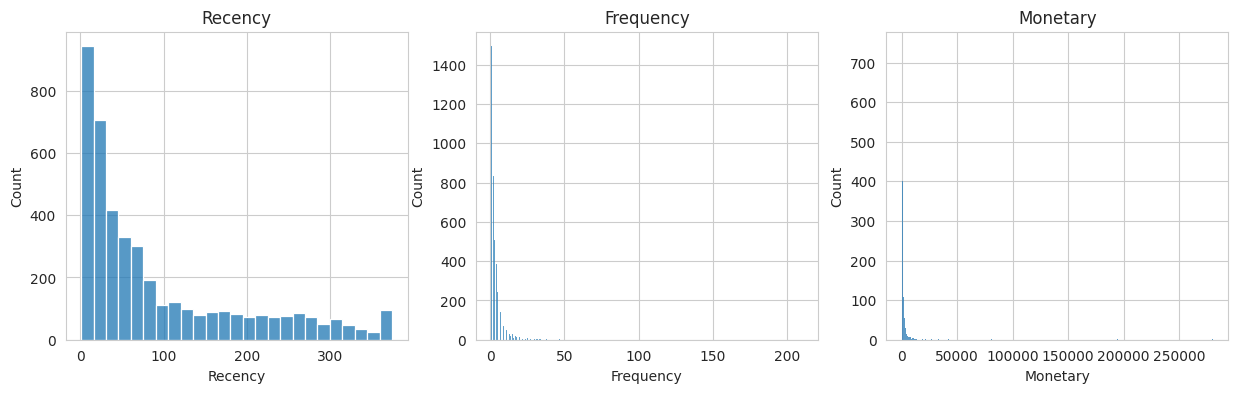

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

sns.histplot(rfm['Recency'], ax=ax[0])
ax[0].set_title('Recency')

sns.histplot(rfm['Frequency'], ax=ax[1])
ax[1].set_title('Frequency')

sns.histplot(rfm['Monetary'], ax=ax[2])
ax[2].set_title('Monetary')

plt.show()

### Insight

- Recency shows variation in how recently customers purchased
- Frequency and Monetary are highly skewed
- Indicates presence of both low-value and high-value customers

**8.3 RFM Scoring**

In [ ]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

**8.4 Segment Customers**

In [ ]:
def segment(row):
    if row['RFM_Score'] == '444':
        return 'Best Customers'
    elif row['F_score'] == 4:
        return 'Loyal Customers'
    elif row['R_score'] == 1:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

**8.5 Segment Visualisation**

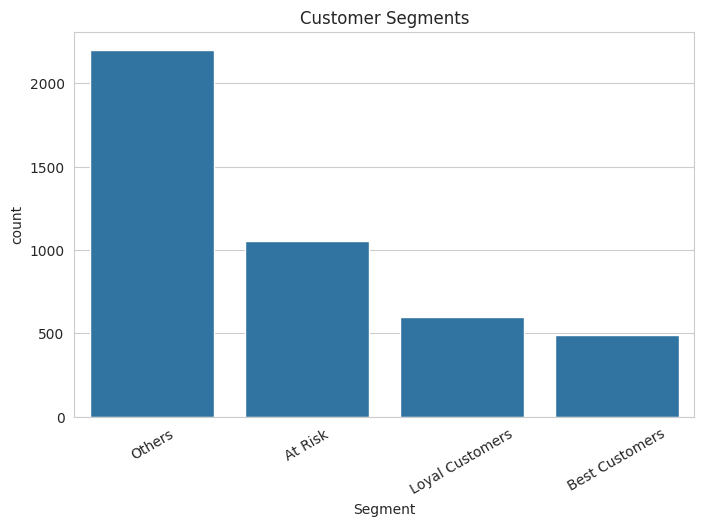

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index)

plt.title('Customer Segments')
plt.xticks(rotation=30)
plt.show()

**8.6 Revenue by Segment**

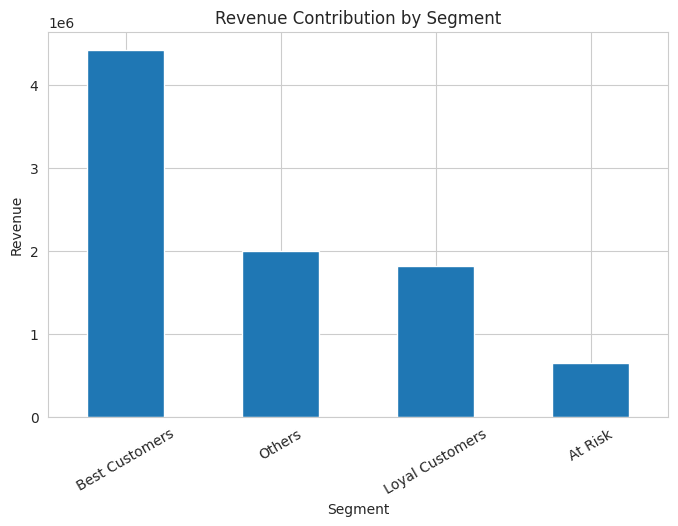

In [ ]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

segment_revenue.plot(kind='bar', figsize=(8,5))
plt.title('Revenue Contribution by Segment')
plt.ylabel('Revenue')
plt.xticks(rotation=30)
plt.show()

### Insight

- A small segment of customers contributes a large portion of total revenue
- High-value segments are critical for business profitability
- Identifying and targeting these customers can significantly improve retention and revenue

# **9. Customer Clustering (K-Means)**


Clustering is used to group customers into segments based on purchasing behaviour, without predefined labels.

**9.1 Prepare Data**

In [ ]:
from sklearn.preprocessing import StandardScaler

X = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature Scaling
# - RFM variables have different scales
# - Scaling ensures equal contribution to clustering

**9.2 Elbow Method**

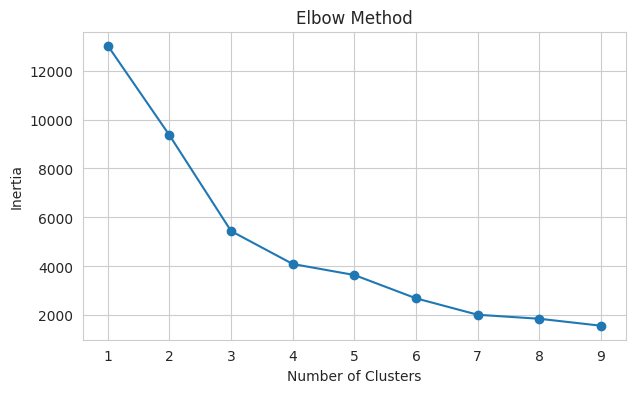

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1,10), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

### Insight

- The elbow point indicates the optimal number of clusters
- Helps balance model simplicity and performance

**9.3 Apply K-Means**

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

**9.4 Cluster Visualization**

**Label Clusters**

In [ ]:
def label_cluster(row):
    if row['Frequency'] > rfm['Frequency'].median() and row['Monetary'] > rfm['Monetary'].median():
        return 'High Value'
    elif row['Recency'] > rfm['Recency'].median():
        return 'At Risk'
    else:
        return 'Regular'

rfm['Cluster_Label'] = rfm.apply(label_cluster, axis=1)

**9.5 Assign Meaningful Labels**

In [ ]:
cluster_map = {
    2: 'VIP Customers',
    0: 'Loyal Customers',
    3: 'Moderate Customers',
    1: 'At Risk Customers'
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_map)


In [ ]:
rfm[['Cluster', 'Cluster_Label']].head()

,Cluster,Cluster_Label
0,0,Loyal Customers
1,3,Moderate Customers
2,3,Moderate Customers
3,3,Moderate Customers
4,1,At Risk Customers


In [ ]:
rfm['Cluster_Label'].value_counts()

,count
Cluster_Label,
Moderate Customers,3053
At Risk Customers,1062
Loyal Customers,211
VIP Customers,13


**9.6 Visualise Clusters with Labels**

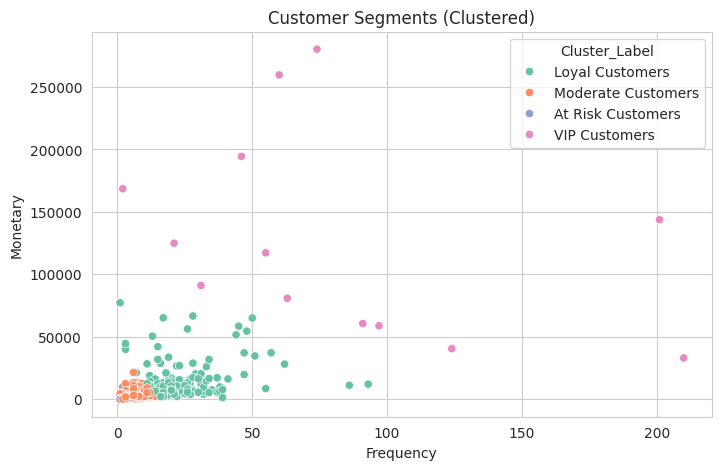

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster_Label',
    palette='Set2'
)

plt.title('Customer Segments (Clustered)')
plt.show()

**9.7 Revenue by Cluster**

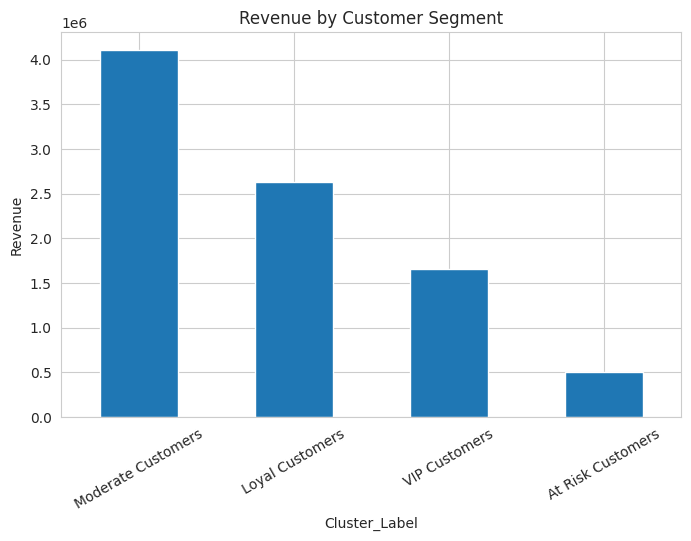

In [ ]:
cluster_revenue = (
    rfm.groupby('Cluster_Label')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

cluster_revenue.plot(kind='bar', figsize=(8,5))
plt.title('Revenue by Customer Segment')
plt.ylabel('Revenue')
plt.xticks(rotation=30)
plt.show()

### Insight

- Moderate customers form the largest segment and contribute a significant portion of total revenue due to their volume  
- VIP customers, although very few, have the highest spending per customer  

This highlights two key strategies:
- Retain VIP customers for high-value transactions  
- Upsell moderate customers to increase their value  

**9.8 Segment Size vs Value**

In [ ]:
cluster_counts = rfm['Cluster_Label'].value_counts()

print(cluster_counts)
print(cluster_revenue)

Cluster_Label
Moderate Customers    3053
At Risk Customers     1062
Loyal Customers        211
VIP Customers           13
Name: count, dtype: int64
Cluster_Label
Moderate Customers    4104099.093
Loyal Customers       2623803.290
VIP Customers         1653443.470
At Risk Customers      505863.041
Name: Monetary, dtype: float64


In [ ]:
rfm.groupby('Cluster_Label')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster_Label,,,
At Risk Customers,248.564030,1.551789,476.330547
Loyal Customers,15.672986,22.047393,12435.086682
Moderate Customers,43.910580,3.655748,1344.284013
VIP Customers,7.384615,82.692308,127187.959231


### Cluster Insights

- VIP customers have the highest value, with significantly higher purchase frequency and spending  
- Loyal customers contribute consistent revenue with strong engagement  
- Moderate customers form the largest group with lower individual value but potential for growth  
- At-risk customers show low engagement and long inactivity, indicating churn risk  

# **Revenue Contribution**

In [ ]:
cluster_revenue_pct = (
    rfm.groupby('Cluster_Label')['Monetary']
    .sum()
)

cluster_revenue_pct = cluster_revenue_pct / cluster_revenue_pct.sum() * 100
cluster_revenue_pct

,Monetary
Cluster_Label,
At Risk Customers,5.692035
Loyal Customers,29.523367
Moderate Customers,46.179843
VIP Customers,18.604755


# **Final Cluster Insights**

- Moderate customers contribute the largest share of total revenue (~46.2%) due to their large population, despite lower individual spending  

- Loyal customers contribute a strong portion of revenue (~29.5%) with consistent purchasing behaviour, forming a stable revenue base  

- VIP customers, although a very small segment, contribute ~18.6% of total revenue with extremely high spending per customer (127K), making them critical for profitability  

- At-risk customers contribute the least (~5.7%) and show low engagement and long inactivity, indicating high churn risk  

# **10. Business Recommendations & Project Summary**


**10.1 Business Recommendations:**


* Focus on retaining VIP customers, as a very small group (~18.6% of revenue) drives high-value transactions.

* Target moderate customers (~46.2% of revenue) with upselling and cross-selling to increase their spending.

* Maintain engagement with loyal customers (~29.5%) to keep a stable and consistent revenue base.

* Re-engage at-risk customers (~5.7%) through targeted campaigns to reduce churn.

* Prioritize top-performing products to optimize inventory and sales.

* Explore growth opportunities in international markets beyond the UK.

**10.2 Project Summary**


* Analyzed e-commerce transaction data to understand revenue drivers and customer behaviour.

* Identified skewed revenue distribution, with a small group of customers contributing high value.

* Performed RFM analysis to segment customers based on recency, frequency, and spending.

* Applied K-Means clustering to identify VIP, loyal, moderate, and at-risk customer segments/

* Found that moderate customers contribute the largest share of revenue (~46.2%), while VIP customers have the highest value per customer.

* Derived actionable insights to improve customer retention, engagement, and overall revenue.